In [ ]:
# Student Name: Amir Gharghabi
# Student ID: 810102217
# HW: 3
# Q: 5

In [32]:
import pandas as pd
import numpy as np

In [73]:
# Specify the path to the data file
file_path = "data/Ecommerce_Customers"
# Read the data into a pandas DataFrame
df = pd.read_csv(file_path)
# Display basic information about the DataFrame
print("DataFrame Information:")
print(df.info())
print("_______________________________________________")
# Display summary statistics of the DataFrame
print("\nDataFrame Descriptive Statistics:")
df.describe()

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB
None
_______________________________________________

DataFrame Descriptive Statistics:


,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

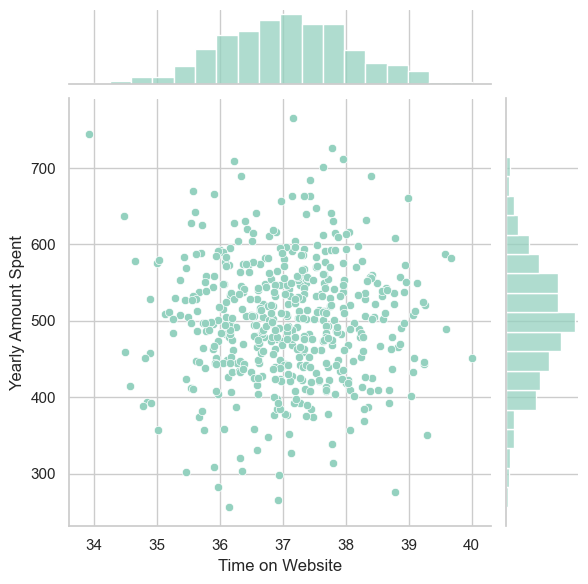

In [6]:
# Assuming 'df' is your DataFrame with 'Yearly Amount Spent' and 'Time on Website' columns
sns.set(style="whitegrid", palette="GnBu_d")
# Create a joint plot
sns.jointplot(x='Time on Website', y='Yearly Amount Spent', data=df)
# Display the plot
plt.show()

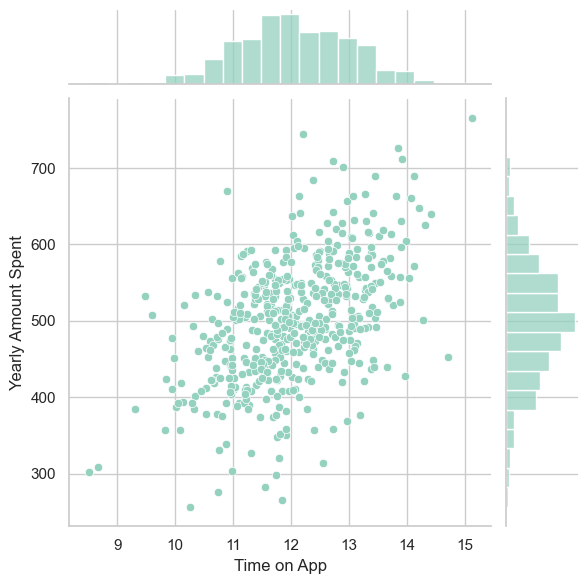

In [7]:
# Assuming 'df' is your DataFrame with 'Yearly Amount Spent' and 'Time on App' columns
sns.set(style="whitegrid", palette="GnBu_d")
# Create a joint plot
sns.jointplot(x='Time on App', y='Yearly Amount Spent', data=df)
# Display the plot
plt.show()

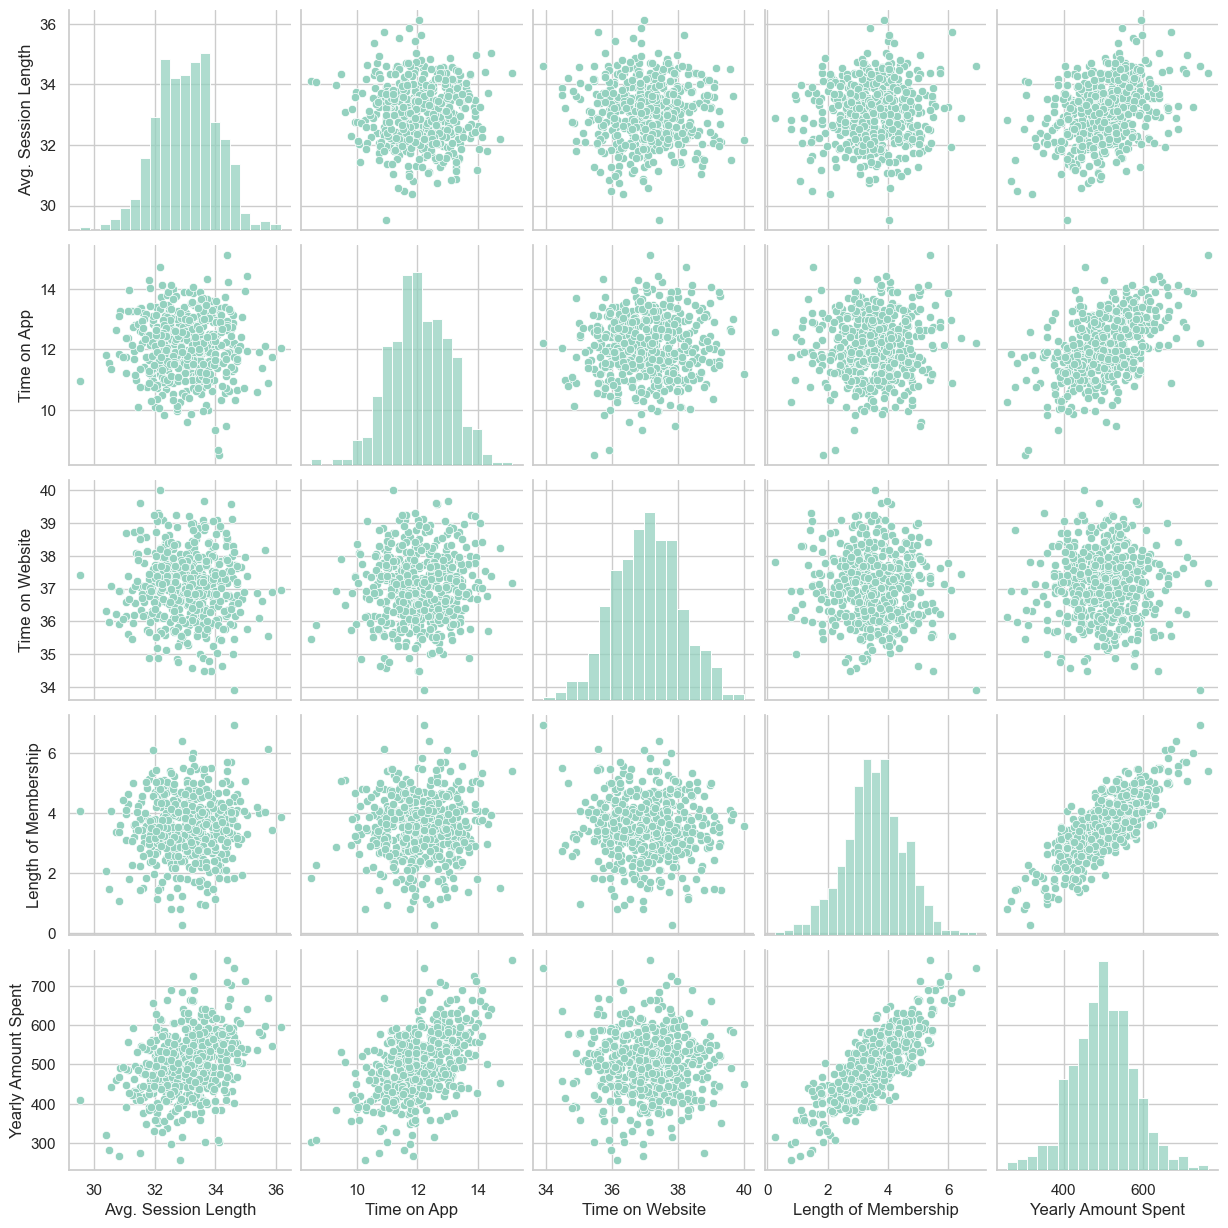

In [8]:
# 5.4
# Create a pair plot
sns.pairplot(df)

# Display the plot
plt.show()

In [40]:
X = df.drop(['Yearly Amount Spent', 'Email', 'Address', 'Avatar'], axis=1)
y = df['Yearly Amount Spent']  # Target variable

# Display the first few rows of X and y for verification
print("Features (X):")
print(X.head())

print("\nLable(y):")
print(y.head())

Features (X):
   Avg. Session Length  Time on App  Time on Website  Length of Membership
0            34.497268    12.655651        39.577668              4.082621
1            31.926272    11.109461        37.268959              2.664034
2            33.000915    11.330278        37.110597              4.104543
3            34.305557    13.717514        36.721283              3.120179
4            33.330673    12.795189        37.536653              4.446308

Lable(y):
0    587.951054
1    392.204933
2    487.547505
3    581.852344
4    599.406092
Name: Yearly Amount Spent, dtype: float64


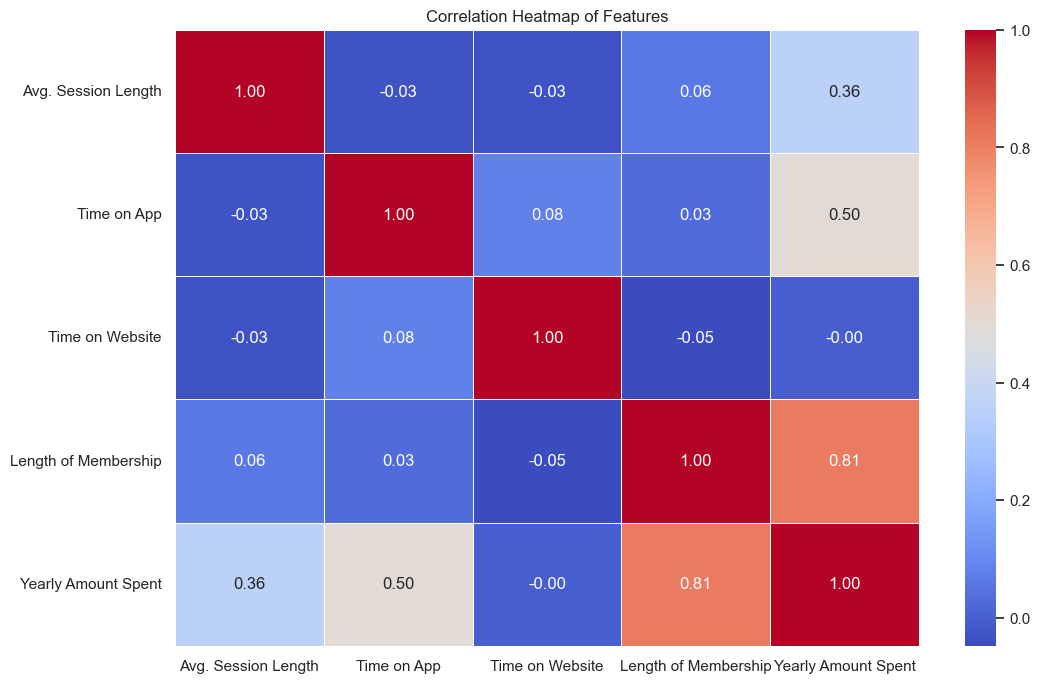

In [41]:
correlation_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Create a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Show the plot
plt.title("Correlation Heatmap of Features")
plt.show()

In [42]:
# Check for missing values
print(df.isnull().sum())

# Handle missing values (example: fill with mean)
df.fillna(df.mean(), inplace=True)

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [37]:
print(X)

     Avg. Session Length  Time on App  Time on Website  Length of Membership  \
0              34.497268    12.655651        39.577668              4.082621   
1              31.926272    11.109461        37.268959              2.664034   
2              33.000915    11.330278        37.110597              4.104543   
3              34.305557    13.717514        36.721283              3.120179   
4              33.330673    12.795189        37.536653              4.446308   
..                   ...          ...              ...                   ...   
495            33.237660    13.566160        36.417985              3.746573   
496            34.702529    11.695736        37.190268              3.576526   
497            32.646777    11.499409        38.332576              4.958264   
498            33.322501    12.391423        36.840086              2.336485   
499            33.715981    12.418808        35.771016              2.735160   

     Yearly Amount Spent  
0           

In [43]:
# Standardize the numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=101)

# Display the shapes of the resulting sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (350, 4)
X_test shape: (150, 4)
y_train shape: (350,)
y_test shape: (150,)


In [46]:
print (X_train)

[[-1.54042682 -0.71731476 -0.02073524  0.27826587]
 [-1.20057318  2.00094393 -0.037818    0.20511689]
 [ 0.20678752 -0.54120777  0.06695944  1.13133221]
 ...
 [-1.23563077  0.41144876  0.36509164 -0.55968868]
 [ 0.83319106 -0.4708972   0.02722264  0.18005776]
 [-0.87068865 -0.67025612  1.12636226  1.27705826]]


In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [54]:
# Create a Linear Regression model
model = LinearRegression()
# Train the model on the training set
model.fit(X_train, y_train)

LinearRegression()

In [56]:
# Make predictions on the test set
y_pred = model.predict(X_test)


Model Evaluation:

_______________________
Mean Squared Error:  79.81305165097478
Root Mean Squared Error:  8.933815066978653
Mean Absolute Error:  7.228148653430847
R-squared (R2) Score:  0.9890046246741234


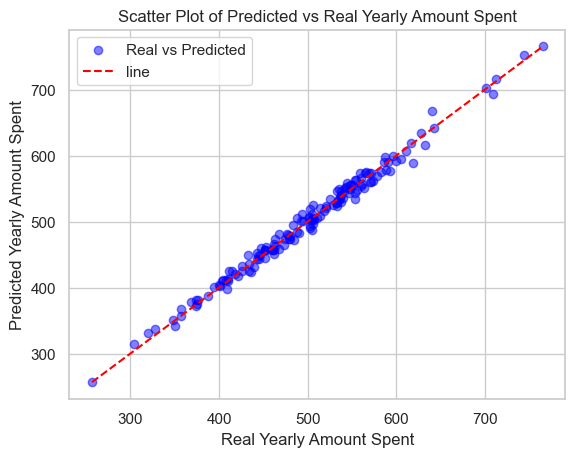

In [75]:
plt.scatter(y_test, y_pred, alpha=0.5, c='blue', label='Real vs Predicted')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', label='line')  # Diagonal line for perfect prediction
plt.title('Scatter Plot of Predicted vs Real Yearly Amount Spent')
plt.xlabel('Real Yearly Amount Spent')
plt.ylabel('Predicted Yearly Amount Spent')
plt.legend()
plt.show()

In [62]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("Model Evaluation:")
print("_______________________")
print(f'Mean Squared Error: ', mse)
print(f'Root Mean Squared Error: ', rmse)
print(f'Mean Absolute Error: ', mae)
print(f'R-squared (R2) Score: ', r2)

Model Evaluation:
_______________________
Mean Squared Error:  79.81305165097478
Root Mean Squared Error:  8.933815066978653
Mean Absolute Error:  7.228148653430847
R-squared (R2) Score:  0.9890046246741234


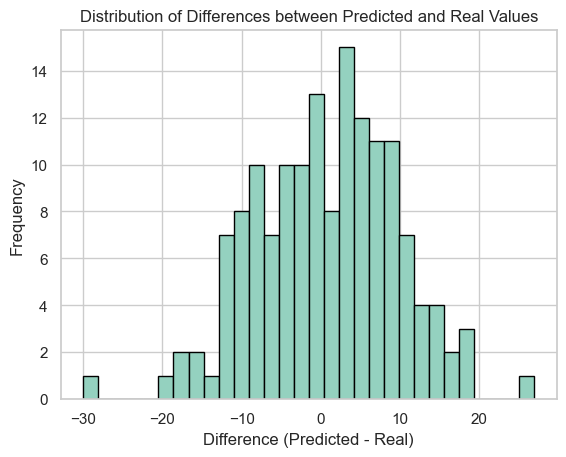

In [63]:
# Calculate the differences between predicted and real values
differences = y_pred - y_test

# Plot a histogram of the differences
plt.hist(differences, bins=30, edgecolor='black')
plt.title('Distribution of Differences between Predicted and Real Values')
plt.xlabel('Difference (Predicted - Real)')
plt.ylabel('Frequency')
plt.show()

In [79]:
model.coef_

array([25.76252659, 38.32855202,  0.19220992, 61.17355707])

In [ ]:
# End of Q5